# JAX

این سخنرانی مقدمه‌ای کوتاه بر [Google JAX](https://github.com/jax-ml/jax) ارائه می‌دهد.

JAX یک کتابخانه محاسبات علمی با کارایی بالا است که موارد زیر را فراهم می‌کند:

* یک رابط شبیه [NumPy](https://en.wikipedia.org/wiki/NumPy) که می‌تواند به صورت خودکار در CPUها و GPUها موازی‌سازی شود،
* یک کامپایلر just-in-time برای تسریع طیف گسترده‌ای از عملیات عددی، و
* [تمایز خودکار](https://en.wikipedia.org/wiki/Automatic_differentiation).

به طور فزاینده‌ای، JAX همچنین [روتین‌های محاسبات علمی تخصصی‌تری](https://docs.jax.dev/en/latest/jax.scipy.html) را حفظ و ارائه می‌دهد، مانند آنهایی که در ابتدا در [SciPy](https://en.wikipedia.org/wiki/SciPy) یافت می‌شدند.

علاوه بر آنچه در Anaconda موجود است، این سخنرانی به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install jax quantecon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.7 MB/s  0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/83.3 MB ? eta -:--:--
   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.2/83.3 MB 105.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 37.7/83.3 MB 94.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 63.4/83.3 MB 105.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 99.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/5.0 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 146.9 MB/s  0:00:00

   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [quantecon]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [jaxlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [jaxlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [jaxlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [jaxlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [jaxlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.7 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/83.3 MB ? eta -:--:--

   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.2/83.3 MB 105.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 37.7/83.3 MB 94.1 MB/s eta 0:00:01

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [jax]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [jax]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [jax]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [jax]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [jax]


```{include} _admonition/gpu.md
```

## JAX به عنوان جایگزین NumPy

یکی از ویژگی‌های جذاب JAX این است که، هر زمان که امکان‌پذیر باشد، عملیات پردازش آرایه‌های آن با API NumPy مطابقت دارد.

این بدان معناست که در بسیاری از موارد، می‌توانیم از JAX به عنوان جایگزین مستقیم NumPy استفاده کنیم.

بیایید به شباهت‌ها و تفاوت‌های بین JAX و NumPy نگاه کنیم.

### شباهت‌ها

ما از import‌های زیر استفاده خواهیم کرد

In [2]:
import jax
import quantecon as qe

علاوه بر این، ما `import numpy as np` را با موارد زیر جایگزین می‌کنیم

In [3]:
import jax.numpy as jnp

اکنون می‌توانیم از `jnp` به جای `np` برای عملیات معمول آرایه استفاده کنیم:

In [4]:
a = jnp.asarray((1.0, 3.2, -1.5))

In [5]:
print(a)

[ 1.   3.2 -1.5]


In [6]:
print(jnp.sum(a))

2.6999998


In [7]:
print(jnp.mean(a))

0.9


In [8]:
print(jnp.dot(a, a))

13.490001


با این حال، شیء آرایه `a` یک آرایه NumPy نیست:

In [9]:
a

Array([ 1. ,  3.2, -1.5], dtype=float32)

In [10]:
type(a)

jaxlib._jax.ArrayImpl

حتی نگاشت‌های با مقدار اسکالر روی آرایه‌ها، آرایه‌های JAX را برمی‌گردانند.

In [11]:
jnp.sum(a)

Array(2.6999998, dtype=float32)

عملیات روی آرایه‌های با ابعاد بالاتر نیز مشابه NumPy هستند:

In [12]:
A = jnp.ones((2, 2))
B = jnp.identity(2)
A @ B

Array([[1., 1.],
       [1., 1.]], dtype=float32)

رابط آرایه JAX همچنین زیربسته `linalg` را فراهم می‌کند:

In [13]:
jnp.linalg.inv(B)   # Inverse of identity is identity

Array([[1., 0.],
       [0., 1.]], dtype=float32)

In [14]:
jnp.linalg.eigh(B)  # Computes eigenvalues and eigenvectors

EighResult(eigenvalues=Array([1., 1.], dtype=float32), eigenvectors=Array([[1., 0.],
       [0., 1.]], dtype=float32))

### تفاوت‌ها

اکنون به برخی از تفاوت‌های بین عملیات آرایه JAX و NumPy نگاه کنیم.

#### دقت

یکی از تفاوت‌های بین NumPy و JAX این است که JAX به طور پیش‌فرض از اعداد اعشاری 32 بیتی استفاده می‌کند.

این به این دلیل است که JAX اغلب برای محاسبات GPU استفاده می‌شود و بیشتر محاسبات GPU از اعداد اعشاری 32 بیتی استفاده می‌کنند.

استفاده از اعداد اعشاری 32 بیتی می‌تواند منجر به افزایش سرعت قابل توجه با از دست دادن کم دقت شود.

با این حال، برای برخی محاسبات دقت مهم است.

در این موارد، اعداد اعشاری 64 بیتی را می‌توان از طریق دستور زیر اعمال کرد

In [15]:
jax.config.update("jax_enable_x64", True)

بیایید بررسی کنیم که این کار می‌کند:

In [16]:
jnp.ones(3)

Array([1., 1., 1.], dtype=float64)

#### تغییرناپذیری

به عنوان یک جایگزین NumPy، تفاوت مهم‌تر این است که آرایه‌ها به عنوان **تغییرناپذیر** در نظر گرفته می‌شوند.

برای مثال، با NumPy می‌توانیم بنویسیم

In [17]:
import numpy as np
a = np.linspace(0, 1, 3)
a

array([0. , 0.5, 1. ])

و سپس داده‌ها را در حافظه تغییر دهیم:

In [18]:
a[0] = 1
a

array([1. , 0.5, 1. ])

در JAX این کار شکست می‌خورد:

In [19]:
a = jnp.linspace(0, 1, 3)
a

Array([0. , 0.5, 1. ], dtype=float64)

In [20]:
a[0] = 1

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

در راستای تغییرناپذیری، JAX از عملیات درجا پشتیبانی نمی‌کند:

In [21]:
a = np.array((2, 1))
a.sort()    # Unlike NumPy, does not mutate a
a

array([1, 2])

In [22]:
a = jnp.array((2, 1))
a_new = a.sort()   # Instead, the sort method returns a new sorted array
a, a_new

(Array([2, 1], dtype=int64), Array([1, 2], dtype=int64))

طراحان JAX تصمیم گرفتند آرایه‌ها را تغییرناپذیر کنند زیرا JAX از سبک [برنامه‌نویسی تابعی](https://en.wikipedia.org/wiki/Functional_programming) استفاده می‌کند.

این انتخاب طراحی دارای پیامدهای مهمی است که در ادامه آن را بررسی می‌کنیم!

#### راه‌حل جایگزین

توجه می‌کنیم که JAX نسخه‌ای از تغییر درجای آرایه را با استفاده از [متد `at`](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html) فراهم می‌کند.

In [23]:
a = jnp.linspace(0, 1, 3)

اعمال `at[0].set(1)` یک کپی جدید از `a` را با عنصر اول تنظیم شده بر 1 برمی‌گرداند

In [24]:
a = a.at[0].set(1)
a

Array([1. , 0.5, 1. ], dtype=float64)

بدیهی است که استفاده از `at` معایبی دارد:

* نحو دست و پاگیر است و
* می‌خواهیم از ایجاد آرایه‌های جدید در حافظه هر بار که یک مقدار منفرد را تغییر می‌دهیم، اجتناب کنیم!

از این رو، در بیشتر موارد، سعی می‌کنیم از این نحو اجتناب کنیم.

(اگرچه در واقع می‌تواند داخل توابع کامپایل‌شده JIT کارآمد باشد -- اما بیایید این را فعلاً کنار بگذاریم.)


## برنامه‌نویسی تابعی

از مستندات JAX:

*هنگام پیاده‌روی در حومه ایتالیا، مردم از گفتن این که JAX دارای "una anima di pura programmazione funzionale" است، تردید نخواهند کرد.*

به عبارت دیگر، JAX یک سبک برنامه‌نویسی تابعی را فرض می‌کند.

### توابع خالص

پیامد اصلی این است که توابع JAX باید خالص باشند.

[توابع خالص](https://en.wikipedia.org/wiki/Pure_function) دارای ویژگی‌های زیر هستند:

1. *قطعی (Deterministic)*
2. *بدون عوارض جانبی*

[قطعی](https://en.wikipedia.org/wiki/Deterministic_algorithm) به این معناست که

* ورودی یکسان $\implies$ خروجی یکسان
* خروجی‌ها به وضعیت سراسری وابسته نیستند

به طور خاص، توابع خالص همیشه نتیجه یکسانی را برمی‌گردانند اگر با ورودی‌های یکسان فراخوانی شوند.

[بدون عوارض جانبی](https://en.wikipedia.org/wiki/Side_effect_(computer_science)) به این معناست که تابع

* وضعیت سراسری را تغییر نمی‌دهد
* داده‌های ارسال شده به تابع را تغییر نمی‌دهد (داده‌های تغییرناپذیر)



### مثال‌ها

در اینجا مثالی از یک تابع *غیرخالص* آورده شده است

In [25]:
tax_rate = 0.1
prices = [10.0, 20.0]

def add_tax(prices):
    for i, price in enumerate(prices):
        prices[i] = price * (1 + tax_rate)
    print('Post-tax prices: ', prices)
    return prices

این تابع نمی‌تواند خالص باشد زیرا

* عوارض جانبی --- متغیر سراسری `prices` را تغییر می‌دهد
* غیرقطعی --- تغییر در متغیر سراسری `tax_rate` خروجی‌های تابع را تغییر خواهد داد، حتی با آرایه ورودی یکسان `prices`.

در اینجا یک نسخه *خالص* آورده شده است

In [26]:
tax_rate = 0.1
prices = (10.0, 20.0)

def add_tax_pure(prices, tax_rate):
    new_prices = [price * (1 + tax_rate) for price in prices]
    return new_prices

این نسخه خالص تمام وابستگی‌ها را از طریق آرگومان‌های تابع صریح می‌کند و هیچ وضعیت خارجی را تغییر نمی‌دهد.

اکنون که می‌فهمیم توابع خالص چیستند، بیایید بررسی کنیم که چگونه رویکرد JAX به اعداد تصادفی این خلوص را حفظ می‌کند.


## اعداد تصادفی

اعداد تصادفی در JAX نسبت به آنچه در NumPy یا Matlab می‌یابید بسیار متفاوت هستند.

در ابتدا ممکن است نحو را نسبتاً پرمخاطب بیابید.

اما به زودی متوجه خواهید شد که نحو و معناشناسی برای حفظ سبک برنامه‌نویسی تابعی که به تازگی مورد بحث قرار دادیم، ضروری است.

علاوه بر این، کنترل کامل وضعیت تصادفی برای برنامه‌نویسی موازی، مانند زمانی که می‌خواهیم آزمایش‌های مستقل را در چندین رشته اجرا کنیم، ضروری است.


### تولید اعداد تصادفی

در JAX، وضعیت مولد اعداد تصادفی به صورت صریح کنترل می‌شود.

ابتدا یک کلید تولید می‌کنیم که مولد اعداد تصادفی را seed می‌کند.

In [27]:
seed = 1234
key = jax.random.PRNGKey(seed)

اکنون می‌توانیم از کلید برای تولید چند عدد تصادفی استفاده کنیم:

In [28]:
x = jax.random.normal(key, (3, 3))
x

Array([[-0.54019824,  0.43957585, -0.01978102],
       [ 0.90665474, -0.90831359,  1.32846635],
       [ 0.20408174,  0.93096529,  3.30373914]], dtype=float64)

اگر دوباره از همان کلید استفاده کنیم، در همان seed مقداردهی اولیه می‌کنیم، بنابراین اعداد تصادفی یکسان هستند:

In [29]:
jax.random.normal(key, (3, 3))

Array([[-0.54019824,  0.43957585, -0.01978102],
       [ 0.90665474, -0.90831359,  1.32846635],
       [ 0.20408174,  0.93096529,  3.30373914]], dtype=float64)

برای تولید یک نمونه (شبه) مستقل، یک گزینه "تقسیم" کلید موجود است:

In [30]:
key, subkey = jax.random.split(key)

In [31]:
jax.random.normal(key, (3, 3))

Array([[ 1.24104247,  0.12018902, -2.23990047],
       [ 0.70507261, -0.85702845, -1.24582014],
       [ 0.38454486,  1.32117717,  0.56866901]], dtype=float64)

In [32]:
jax.random.normal(subkey, (3, 3))

Array([[ 0.07627173, -1.30349831,  0.86524323],
       [-0.75550773,  0.63958052,  0.47052126],
       [-1.72866044, -1.14696564, -1.23328892]], dtype=float64)

این نحو برای کاربر NumPy یا Matlab غیرعادی به نظر می‌رسد --- اما وقتی به برنامه‌نویسی موازی پیش می‌رویم، منطقی خواهد بود.

تابع زیر `k` ماتریس تصادفی `n x n` (شبه) مستقل را با استفاده از `split` تولید می‌کند.

In [33]:
def gen_random_matrices(key, n=2, k=3):
    matrices = []
    for _ in range(k):
        key, subkey = jax.random.split(key)
        A = jax.random.uniform(subkey, (n, n))
        matrices.append(A)
        print(A)
    return matrices

In [34]:
seed = 42
key = jax.random.PRNGKey(seed)
matrices = gen_random_matrices(key)

[[0.74211901 0.54715578]
 [0.05988742 0.32206803]]
[[0.65877976 0.57087415]
 [0.97301903 0.10138266]]
[[0.68745522 0.25974132]
 [0.06595873 0.83589118]]


همچنین می‌توانیم هنگام تکرار در یک حلقه از `fold_in` استفاده کنیم:

In [35]:
def gen_random_matrices(key, n=2, k=3):
    matrices = []
    for i in range(k):
        step_key = jax.random.fold_in(key, i)
        A = jax.random.uniform(step_key, (n, n))
        matrices.append(A)
        print(A)
    return matrices

In [36]:
key = jax.random.PRNGKey(seed)
matrices = gen_random_matrices(key)

[[0.23566993 0.39719189]
 [0.95367373 0.42397776]]
[[0.74211901 0.54715578]
 [0.05988742 0.32206803]]
[[0.37386727 0.66444882]
 [0.80253222 0.42934555]]


### چرا وضعیت تصادفی صریح؟

چرا JAX به این رویکرد نسبتاً پرمخاطب برای تولید اعداد تصادفی نیاز دارد؟

یکی از دلایل حفظ توابع خالص است.

بیایید ببینیم که چگونه تولید اعداد تصادفی با توابع خالص با مقایسه NumPy و JAX مرتبط است.

#### رویکرد NumPy

در NumPy، تولید اعداد تصادفی با حفظ وضعیت سراسری پنهان کار می‌کند.

هر بار که یک تابع تصادفی را فراخوانی می‌کنیم، این وضعیت به‌روزرسانی می‌شود:

In [37]:
np.random.seed(42)
print(np.random.randn())   # Updates state of random number generator
print(np.random.randn())   # Updates state of random number generator

0.4967141530112327
-0.13826430117118466


هر فراخوانی یک مقدار متفاوت را برمی‌گرداند، حتی اگر ما همان تابع را با همان ورودی‌ها (بدون آرگومان، در این مورد) فراخوانی می‌کنیم.

این تابع *خالص نیست* زیرا:

* غیرقطعی است: ورودی‌های یکسان (در این مورد هیچ) خروجی‌های متفاوت می‌دهند
* دارای عوارض جانبی است: وضعیت مولد اعداد تصادفی سراسری را تغییر می‌دهد


#### رویکرد JAX

همانطور که در بالا دیدیم، JAX رویکرد متفاوتی اتخاذ می‌کند و تصادفی بودن را از طریق کلیدها صریح می‌کند.

برای مثال،

In [38]:
def random_sum_jax(key):
    key1, key2 = jax.random.split(key)
    x = jax.random.normal(key1)
    y = jax.random.normal(key2)
    return x + y

با همان کلید، همیشه نتیجه یکسانی دریافت می‌کنیم:

In [39]:
key = jax.random.PRNGKey(42)
random_sum_jax(key)

Array(-0.07040872, dtype=float64)

In [40]:
random_sum_jax(key)

Array(-0.07040872, dtype=float64)

برای دریافت نمونه‌های جدید باید یک کلید جدید ارائه دهیم.

تابع `random_sum_jax` خالص است زیرا:

* قطعی است: کلید یکسان همیشه خروجی یکسان تولید می‌کند
* بدون عوارض جانبی: هیچ وضعیت پنهانی تغییر نمی‌کند

صریح بودن JAX مزایای قابل توجهی به همراه دارد:

* تکرارپذیری: با استفاده مجدد از کلیدها، تکرار نتایج آسان است
* موازی‌سازی: هر رشته می‌تواند کلید خاص خود را بدون تضاد داشته باشد
* اشکال‌زدایی: نبود وضعیت پنهان استدلال در مورد کد را آسان‌تر می‌کند
* سازگاری با JIT: کامپایلر می‌تواند توابع خالص را به طور تهاجمی‌تری بهینه کند

نکته آخر در بخش بعدی گسترش داده می‌شود.


## کامپایل JIT

کامپایلر just-in-time (JIT) JAX اجرا را با تولید کد ماشین کارآمد که با هم اندازه وظیفه و هم سخت‌افزار متفاوت است، تسریع می‌کند.

### یک مثال ساده

فرض کنید می‌خواهیم تابع کسینوس را در نقاط بسیاری ارزیابی کنیم.

In [41]:
n = 50_000_000
x = np.linspace(0, 10, n)

#### با NumPy

بیایید ابتدا با NumPy امتحان کنیم

In [42]:
with qe.Timer():
    y = np.cos(x)

0.5682 seconds elapsed


و یک بار دیگر.

In [43]:
with qe.Timer():
    y = np.cos(x)

0.5803 seconds elapsed


در اینجا NumPy از یک فایل باینری از پیش ساخته شده، کامپایل شده از کد سطح پایین نوشته شده با دقت، برای اعمال کسینوس به یک آرایه از اعداد اعشاری استفاده می‌کند.

این فایل باینری با NumPy ارسال می‌شود.

#### با JAX

اکنون بیایید با JAX امتحان کنیم.

In [44]:
x = jnp.linspace(0, 10, n)

بیایید همان روش را زمان‌بندی کنیم.

In [45]:
with qe.Timer():
    y = jnp.cos(x)
    jax.block_until_ready(y);

0.3280 seconds elapsed


```{note}
در اینجا، به منظور اندازه‌گیری سرعت واقعی، از متد `block_until_ready` استفاده می‌کنیم تا مفسر را تا زمانی که نتایج محاسبات برگردانده شوند، نگه دارد.

این امر ضروری است زیرا JAX از ارسال ناهمزمان استفاده می‌کند که به مفسر Python اجازه می‌دهد از محاسبات عددی جلوتر برود.

برای کدهای زمان‌بندی نشده، می‌توانید خط حاوی `block_until_ready` را حذف کنید.
```


و بیایید دوباره آن را زمان‌بندی کنیم.

In [46]:
with qe.Timer():
    y = jnp.cos(x)
    jax.block_until_ready(y);

0.2828 seconds elapsed


روی GPU، این کد بسیار سریع‌تر از معادل NumPy آن اجرا می‌شود.

همچنین، معمولاً، اجرای دوم سریع‌تر از اولین اجرا به دلیل کامپایل JIT است.

این به این دلیل است که حتی توابع داخلی مانند `jnp.cos` نیز JIT-کامپایل می‌شوند --- و اجرای اول شامل زمان کامپایل است.

چرا JAX می‌خواهد توابع داخلی مانند `jnp.cos` را به جای ارائه نسخه‌های از پیش کامپایل شده، مانند NumPy، JIT-کامپایل کند؟

دلیل این است که کامپایلر JIT می‌خواهد روی *اندازه* آرایه در حال استفاده (و همچنین نوع داده) تخصصی شود.

اندازه برای تولید کد بهینه شده اهمیت دارد زیرا موازی‌سازی کارآمد نیاز به تطبیق اندازه وظیفه با سخت‌افزار موجود دارد.

به همین دلیل است که JAX منتظر می‌ماند تا اندازه آرایه را قبل از کامپایل ببیند --- که نیاز به یک رویکرد JIT-کامپایل شده به جای ارائه باینری‌های از پیش کامپایل شده دارد.


#### تغییر اندازه آرایه‌ها

در اینجا اندازه ورودی را تغییر می‌دهیم و زمان‌های اجرا را مشاهده می‌کنیم.

In [47]:
x = jnp.linspace(0, 10, n + 1)

In [48]:
with qe.Timer():
    y = jnp.cos(x)
    jax.block_until_ready(y);

0.3304 seconds elapsed


In [49]:
with qe.Timer():
    y = jnp.cos(x)
    jax.block_until_ready(y);

0.2914 seconds elapsed


معمولاً، زمان اجرا افزایش می‌یابد و سپس دوباره کاهش می‌یابد (این روی GPU واضح‌تر خواهد بود).

این به این دلیل است که کامپایلر JIT روی اندازه آرایه تخصصی می‌شود تا موازی‌سازی را بهره‌برداری کند --- و از این رو کد کامپایل شده جدیدی را هنگام تغییر اندازه آرایه تولید می‌کند.


### ارزیابی یک تابع پیچیده‌تر

بیایید همان کار را با یک تابع پیچیده‌تر امتحان کنیم.

In [50]:
def f(x):
    y = np.cos(2 * x**2) + np.sqrt(np.abs(x)) + 2 * np.sin(x**4) - 0.1 * x**2
    return y

#### با NumPy

ابتدا با NumPy امتحان خواهیم کرد

In [51]:
n = 50_000_000
x = np.linspace(0, 10, n)

In [52]:
with qe.Timer():
    y = f(x)

2.2119 seconds elapsed


#### با JAX

اکنون بیایید دوباره با JAX امتحان کنیم.

به عنوان اولین مرحله، `np` را در همه جا با `jnp` جایگزین می‌کنیم:

In [53]:
def f(x):
    y = jnp.cos(2 * x**2) + jnp.sqrt(jnp.abs(x)) + 2 * jnp.sin(x**4) - x**2
    return y

اکنون بیایید آن را زمان‌بندی کنیم.

In [54]:
x = jnp.linspace(0, 10, n)

In [55]:
with qe.Timer():
    y = f(x)
    jax.block_until_ready(y);

0.9369 seconds elapsed


In [56]:
with qe.Timer():
    y = f(x)
    jax.block_until_ready(y);

0.8556 seconds elapsed


نتیجه مشابه مثال `cos` است --- JAX سریع‌تر است، به ویژه در اجرای دوم پس از کامپایل JIT.

علاوه بر این، با JAX، ترفند دیگری در آستین داریم:


### کامپایل کل تابع

کامپایلر just-in-time (JIT) JAX می‌تواند اجرا را در درون توابع با ادغام عملیات جبر خطی در یک هسته بهینه شده واحد تسریع کند.

بیایید این را با تابع `f` امتحان کنیم:

In [57]:
f_jax = jax.jit(f)

In [58]:
with qe.Timer():
    y = f_jax(x)
    jax.block_until_ready(y);

0.5715 seconds elapsed


In [59]:
with qe.Timer():
    y = f_jax(x)
    jax.block_until_ready(y);

0.5475 seconds elapsed


زمان اجرا دوباره بهبود یافته است --- اکنون به این دلیل که تمام عملیات را ادغام کردیم و به کامپایلر اجازه دادیم به طور تهاجمی‌تری بهینه‌سازی کند.

برای مثال، کامپایلر می‌تواند چندین فراخوانی به شتاب‌دهنده سخت‌افزاری و ایجاد تعدادی آرایه میانی را حذف کند.


اتفاقاً، نحو رایج‌تر هنگام هدف قرار دادن یک تابع برای کامپایلر JIT این است

In [60]:
@jax.jit
def f(x):
    pass # put function body here

### کامپایل توابع غیرخالص

اکنون که دیدیم کامپایل JIT چقدر قدرتمند می‌تواند باشد، درک رابطه آن با توابع خالص مهم است.

در حالی که JAX معمولاً هنگام کامپایل توابع ناخالص خطا نمی‌دهد، اجرا غیرقابل پیش‌بینی می‌شود.

در اینجا تصویری از این واقعیت با استفاده از متغیرهای سراسری آورده شده است:

In [61]:
a = 1  # global

@jax.jit
def f(x):
    return a + x

In [62]:
x = jnp.ones(2)

In [63]:
f(x)

Array([2., 2.], dtype=float64)

در کد بالا، مقدار سراسری `a=1` در تابع jitted ادغام می‌شود.

حتی اگر `a` را تغییر دهیم، خروجی `f` تحت تأثیر قرار نخواهد گرفت --- تا زمانی که همان نسخه کامپایل شده فراخوانی شود.

In [64]:
a = 42

In [65]:
f(x)

Array([2., 2.], dtype=float64)

تغییر بعد ورودی باعث کامپایل مجدد تابع می‌شود، در آن زمان تغییر در مقدار `a` اثر می‌گذارد:

In [66]:
x = jnp.ones(3)

In [67]:
f(x)

Array([43., 43., 43.], dtype=float64)

درس اخلاقی داستان: هنگام استفاده از JAX، توابع خالص بنویسید!


### خلاصه

اکنون می‌توانیم ببینیم که چرا هم توسعه‌دهندگان و هم کامپایلرها از توابع خالص بهره می‌برند.

ما توابع خالص را دوست داریم زیرا آنها

* به تست کمک می‌کنند: هر تابع می‌تواند به صورت جداگانه عمل کند
* رفتار قطعی و از این رو تکرارپذیری را ترویج می‌کنند
* از باگ‌هایی که از تغییر وضعیت مشترک ناشی می‌شوند، جلوگیری می‌کنند

کامپایلر توابع خالص و برنامه‌نویسی تابعی را دوست دارد زیرا

* وابستگی‌های داده صریح هستند، که به بهینه‌سازی محاسبات پیچیده کمک می‌کند
* توابع خالص راحت‌تر قابل تمایز هستند (autodiff)
* توابع خالص راحت‌تر موازی‌سازی و بهینه‌سازی می‌شوند (به وضعیت قابل تغییر مشترک وابسته نیستند)


## گرادیان‌ها

JAX می‌تواند از تمایز خودکار برای محاسبه گرادیان‌ها استفاده کند.

این می‌تواند برای بهینه‌سازی و حل سیستم‌های غیرخطی بسیار مفید باشد.

ما کاربردهای قابل توجهی را بعداً در این مجموعه سخنرانی‌ها خواهیم دید.

فعلاً، در اینجا یک تصویر بسیار ساده شامل تابع است

In [68]:
def f(x):
    return (x**2) / 2

بیایید مشتق بگیریم:

In [69]:
f_prime = jax.grad(f)

In [70]:
f_prime(10.0)

Array(10., dtype=float64, weak_type=True)

بیایید تابع و مشتق را رسم کنیم، با توجه به اینکه $f'(x) = x$.

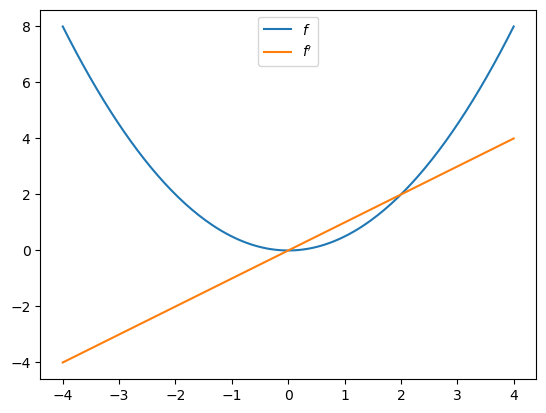

In [71]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x_grid = jnp.linspace(-4, 4, 200)
ax.plot(x_grid, f(x_grid), label="$f$")
ax.plot(x_grid, [f_prime(x) for x in x_grid], label="$f'$")
ax.legend(loc='upper center')
plt.show()

ما بررسی بیشتر تمایز خودکار با JAX را در [ماجراجویی‌ها با تمایز خودکار](https://jax.quantecon.org/autodiff.html) موکول می‌کنیم.


## تمرین‌ها


```{exercise-start}
:label: jax_intro_ex2
```

در بخش تمرین {doc}`سخنرانی ما در مورد Numba <numba>`، ما {ref}`از مونت کارلو برای قیمت‌گذاری یک اختیار خرید اروپایی استفاده کردیم <numba_ex4>`.

کد با چندرشته‌ای مبتنی بر Numba تسریع شد.

سعی کنید نسخه‌ای از این عملیات را برای JAX بنویسید، با استفاده از همان پارامترها.



```{exercise-end}
```


```{solution-start} jax_intro_ex2
:class: dropdown
```
در اینجا یک راه‌حل آورده شده است:

In [72]:
M = 10_000_000

n, β, K = 20, 0.99, 100
μ, ρ, ν, S0, h0 = 0.0001, 0.1, 0.001, 10, 0

@jax.jit
def compute_call_price_jax(β=β,
                           μ=μ,
                           S0=S0,
                           h0=h0,
                           K=K,
                           n=n,
                           ρ=ρ,
                           ν=ν,
                           M=M,
                           key=jax.random.PRNGKey(1)):

    s = jnp.full(M, np.log(S0))
    h = jnp.full(M, h0)

    def update(i, loop_state):
        s, h, key = loop_state
        key, subkey = jax.random.split(key)
        Z = jax.random.normal(subkey, (2, M))
        s = s + μ + jnp.exp(h) * Z[0, :]
        h = ρ * h + ν * Z[1, :]
        new_loop_state = s, h, key
        return new_loop_state

    initial_loop_state = s, h, key
    final_loop_state = jax.lax.fori_loop(0, n, update, initial_loop_state)
    s, h, key = final_loop_state

    expectation = jnp.mean(jnp.maximum(jnp.exp(s) - K, 0))

    return β**n * expectation

```{note}
ما از `jax.lax.fori_loop` به جای حلقه `for` پایتون استفاده می‌کنیم.
این به JAX اجازه می‌دهد حلقه را به طور کارآمد بدون باز کردن آن کامپایل کند،
که زمان کامپایل را برای آرایه‌های بزرگ به طور قابل توجهی کاهش می‌دهد.
```

بیایید یک بار آن را اجرا کنیم تا کامپایل شود:

In [73]:
with qe.Timer():
    compute_call_price_jax().block_until_ready()

5.4211 seconds elapsed


و اکنون بیایید آن را زمان‌بندی کنیم:

In [74]:
with qe.Timer():
    compute_call_price_jax().block_until_ready()

5.0957 seconds elapsed


```{solution-end}
```